In [2]:
import sys
import paddle
import paddleocr

print("Python executable:")
print(sys.executable)

print("\nPython version:")
print(sys.version)

print("\nPaddlePaddle:")
print(paddle.__version__)
print("Device:", paddle.device.get_device())

print("\nPaddleOCR:")
print(paddleocr.__version__)

d:\downloads\misleading-health-infographic-detection\.venv_tf\Lib\site-packages\paddle\utils\cpp_extension\extension_utils.py:712: UserWarning: No ccache found. Please be aware that recompiling all source files may be required. You can download and install ccache from: https://github.com/ccache/ccache/blob/master/doc/INSTALL.md
  warnings.warn(warning_message)
d:\downloads\misleading-health-infographic-detection\.venv_tf\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Python executable:
d:\downloads\misleading-health-infographic-detection\.venv_tf\Scripts\python.exe

Python version:
3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]

PaddlePaddle:
3.3.0
Device: cpu

PaddleOCR:
3.7.0


In [3]:
from pathlib import Path
import json
import re
import os
import sys
import traceback
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import paddle
import paddleocr

from paddleocr import PaddleOCR

print("Python:", sys.version)
print("Python executable:", sys.executable)
print("PaddlePaddle:", paddle.__version__)
print("PaddleOCR:", paddleocr.__version__)
print("Device:", paddle.device.get_device())

Python: 3.12.0 (tags/v3.12.0:0fb18b0, Oct  2 2023, 13:03:39) [MSC v.1935 64 bit (AMD64)]
Python executable: d:\downloads\misleading-health-infographic-detection\.venv_tf\Scripts\python.exe
PaddlePaddle: 3.3.0
PaddleOCR: 3.7.0
Device: cpu


In [4]:
PROJECT_ROOT = Path.cwd().parent

if not (PROJECT_ROOT / "src").exists():
    PROJECT_ROOT = Path.cwd()

print("PROJECT_ROOT:")
print(PROJECT_ROOT)

PHASE11_DIR = PROJECT_ROOT / "outputs" / "phase11"

PHASE12_DIR = PROJECT_ROOT / "outputs" / "phase12"

OCR_RESULTS_DIR = PHASE12_DIR / "ocr_results"
MANIFEST_DIR = PHASE12_DIR / "manifests"
METRICS_DIR = PHASE12_DIR / "metrics"
VIS_DIR = PHASE12_DIR / "visualizations"
REPORTS_DIR = PHASE12_DIR / "reports"

for directory in [
    PHASE12_DIR,
    OCR_RESULTS_DIR,
    MANIFEST_DIR,
    METRICS_DIR,
    VIS_DIR,
    REPORTS_DIR,
]:
    directory.mkdir(parents=True, exist_ok=True)

print("\nPhase 11 directory:")
print(PHASE11_DIR)

print("\nPhase 12 directory:")
print(PHASE12_DIR)

print("\nPhase 12 directories created successfully.")

PROJECT_ROOT:
d:\downloads\misleading-health-infographic-detection

Phase 11 directory:
d:\downloads\misleading-health-infographic-detection\outputs\phase11

Phase 12 directory:
d:\downloads\misleading-health-infographic-detection\outputs\phase12

Phase 12 directories created successfully.


In [5]:
for path in [
    PHASE11_DIR / "datasets",
    PHASE11_DIR / "metrics",
    PHASE11_DIR / "checkpoints",
    PHASE11_DIR / "reports",
]:
    print("\n", path)
    print("Exists:", path.exists())
    
    if path.exists():
        items = list(path.iterdir())
        print("Items:", len(items))
        for item in items[:10]:
            print("  ", item.name)


 d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets
Exists: True
Items: 3
   final_test.csv
   final_train.csv
   final_validation.csv

 d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics
Exists: True
Items: 6
   classification_report.txt
   confusion_matrix.csv
   final_test_metrics.json
   source_wise_metrics.csv
   training_history.csv
   validation_threshold_analysis.csv

 d:\downloads\misleading-health-infographic-detection\outputs\phase11\checkpoints
Exists: True
Items: 2
   best_multimodal_model.keras
   best_multimodal_model.weights.h5

 d:\downloads\misleading-health-infographic-detection\outputs\phase11\reports
Exists: True
Items: 3
   experiment_config.json
   phase11_final_report.md
   phase11_final_summary.json


In [6]:
IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}

candidate_roots = [
    PROJECT_ROOT / "outputs" / "phase11",
    PROJECT_ROOT / "outputs" / "phase10",
    PROJECT_ROOT / "outputs" / "phase9",
    PROJECT_ROOT / "data",
]

image_candidates = []

for root in candidate_roots:
    if root.exists():
        for p in root.rglob("*"):
            if p.is_file() and p.suffix.lower() in IMAGE_EXTENSIONS:
                image_candidates.append(p)

image_candidates = sorted(set(image_candidates))

print("Total image files found:", len(image_candidates))

for p in image_candidates[:30]:
    print(p)

Total image files found: 48840
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\00339007006077.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\00795994017065.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\01001540004402.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\01499440003158.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\01729694006399.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\02267499005481.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\02534409005100.png
d:\downloads\misleading-health-infographic-detection\data\raw\chartqa\ChartQA Dataset\test\png\03672594001226.png
d:\downloads\misleading-health-infographic-detection\data

In [7]:
print("CSV files under outputs/phase11:\n")

phase11_csvs = list((PHASE11_DIR).rglob("*.csv"))

for csv_file in phase11_csvs:
    print(csv_file)

CSV files under outputs/phase11:

d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\conflicting_image_records.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\conflicting_text_records.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\duplicate_image_groups.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\excluded_conflicting_records.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\original_split_summary.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_test.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_train.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_validation.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\error_analysis\all_errors.csv
d:\downloads\misleading-health-infographic-detection\outputs

In [8]:
print("\nJSON files under outputs/phase11:\n")

phase11_jsons = list(PHASE11_DIR.rglob("*.json"))

for json_file in phase11_jsons[:50]:
    print(json_file)


JSON files under outputs/phase11:

d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\final_split_audit.json
d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\pre_split_audit_summary.json
d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\final_test_metrics.json
d:\downloads\misleading-health-infographic-detection\outputs\phase11\reports\experiment_config.json
d:\downloads\misleading-health-infographic-detection\outputs\phase11\reports\phase11_final_summary.json


In [9]:
keywords = [
    "test",
    "val",
    "validation",
    "final",
    "manifest",
    "dataset",
    "split"
]

for csv_file in phase11_csvs:
    name = csv_file.name.lower()
    
    if any(k in name for k in keywords):
        print(csv_file)

d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\original_split_summary.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_test.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_train.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\datasets\final_validation.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\error_analysis\test_predictions.csv
d:\downloads\misleading-health-infographic-detection\outputs\phase11\metrics\validation_threshold_analysis.csv


In [10]:
# ============================================================
# CELL 8 — Inspect candidate Phase 11 CSV files
# ============================================================

csv_inventory = []

for csv_file in phase11_csvs:
    try:
        temp = pd.read_csv(csv_file, nrows=5)

        csv_inventory.append({
            "file": str(csv_file),
            "filename": csv_file.name,
            "columns": list(temp.columns),
            "num_columns": len(temp.columns)
        })

    except Exception as e:
        csv_inventory.append({
            "file": str(csv_file),
            "filename": csv_file.name,
            "columns": [],
            "num_columns": 0,
            "error": str(e)
        })

csv_inventory_df = pd.DataFrame(csv_inventory)

print("Number of CSV files inspected:", len(csv_inventory_df))

display(csv_inventory_df[
    ["filename", "num_columns", "columns"]
])

Number of CSV files inspected: 17


,filename,num_columns,columns
0,conflicting_image_records.csv,14,"[record_key, subset, record_id, label, source,..."
1,conflicting_text_records.csv,14,"[record_key, subset, record_id, label, source,..."
2,duplicate_image_groups.csv,2,"[image_hash, record_count]"
3,excluded_conflicting_records.csv,14,"[record_key, subset, record_id, label, source,..."
4,original_split_summary.csv,3,"[split, label, count]"
5,final_test.csv,15,"[record_key, subset, record_id, label, source,..."
6,final_train.csv,15,"[record_key, subset, record_id, label, source,..."
7,final_validation.csv,15,"[record_key, subset, record_id, label, source,..."
8,all_errors.csv,21,"[record_key, subset, record_id, label, source,..."
9,errors_by_source.csv,4,"[source, total_samples, errors, error_rate]"


In [11]:
# ============================================================
# CELL 9 — Find dataset-like CSV files
# ============================================================

dataset_candidates = []

for item in csv_inventory:
    
    columns = [
        str(c).lower()
        for c in item.get("columns", [])
    ]
    
    has_image = any(
        any(keyword in c for keyword in [
            "image",
            "img",
            "image_path",
            "filepath",
            "file_path"
        ])
        for c in columns
    )
    
    has_label = any(
        any(keyword in c for keyword in [
            "label",
            "target",
            "class"
        ])
        for c in columns
    )
    
    has_source = any(
        any(keyword in c for keyword in [
            "source",
            "dataset"
        ])
        for c in columns
    )
    
    has_split = any(
        any(keyword in c for keyword in [
            "split",
            "subset"
        ])
        for c in columns
    )
    
    score = (
        int(has_image) * 4 +
        int(has_label) * 3 +
        int(has_source) * 2 +
        int(has_split) * 1
    )
    
    if score > 0:
        dataset_candidates.append({
            "file": item["file"],
            "filename": item["filename"],
            "score": score,
            "has_image": has_image,
            "has_label": has_label,
            "has_source": has_source,
            "has_split": has_split,
            "columns": item["columns"]
        })

dataset_candidates_df = pd.DataFrame(
    dataset_candidates
).sort_values(
    "score",
    ascending=False
)

display(dataset_candidates_df)

,file,filename,score,has_image,has_label,has_source,has_split,columns
0,d:\downloads\misleading-health-infographic-det...,conflicting_image_records.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
1,d:\downloads\misleading-health-infographic-det...,conflicting_text_records.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
3,d:\downloads\misleading-health-infographic-det...,excluded_conflicting_records.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
5,d:\downloads\misleading-health-infographic-det...,final_test.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
7,d:\downloads\misleading-health-infographic-det...,final_validation.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
6,d:\downloads\misleading-health-infographic-det...,final_train.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
12,d:\downloads\misleading-health-infographic-det...,test_predictions.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
11,d:\downloads\misleading-health-infographic-det...,false_positives.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
8,d:\downloads\misleading-health-infographic-det...,all_errors.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."
10,d:\downloads\misleading-health-infographic-det...,false_negatives.csv,10,True,True,True,True,"[record_key, subset, record_id, label, source,..."


In [13]:
# ============================================================
# CELL 10 — Select Phase 11 dataset
# ============================================================

DATASET_CSV = Path(
    dataset_candidates_df.iloc[0]["file"]
)

print("Selected dataset:")
print(DATASET_CSV)

Selected dataset:
d:\downloads\misleading-health-infographic-detection\outputs\phase11\audit\conflicting_image_records.csv


In [14]:
df_check = pd.read_csv(DATASET_CSV)

print("Shape:", df_check.shape)

print("\nColumns:")
print(df_check.columns.tolist())

print("\nFirst 5 rows:")
display(df_check.head())

Shape: (154, 14)

Columns:
['record_key', 'subset', 'record_id', 'label', 'source', 'is_english', 'text', 'split', 'image_path', 'local_path', 'resolved_image_path', 'image_hash', 'text_key', 'text_hash']

First 5 rows:


,record_key,subset,record_id,label,source,is_english,text,split,image_path,local_path,resolved_image_path,image_hash,text_key,text_hash
0,MM-COVID19_1,MM-COVID19,1,1,MM-COVID19,True,COVID-19 and PPE: Some of Us Will Die\nWhat yo...,train,human_data/MM-COVID19/1_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...,d:\downloads\misleading-health-infographic-det...,06cef860b1d867fc6ef6d99261c15dd9b54a5809e507ec...,covid-19 and ppe: some of us will die\nwhat yo...,04c487f6aadf272ee9d0e5cddceebe41a1792d3ff415cc...
1,MM-COVID19_10,MM-COVID19,10,1,MM-COVID19,True,Commentary: Lessons on COVID-19 From Low-Incom...,train,human_data/MM-COVID19/10_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...,d:\downloads\misleading-health-infographic-det...,06cef860b1d867fc6ef6d99261c15dd9b54a5809e507ec...,commentary: lessons on covid-19 from low-incom...,90de1a9f3842d4c329137981a2f087ec78bd8f38db7325...
2,MM-COVID19_11,MM-COVID19,11,1,MM-COVID19,True,COMMENTARY: COVID-19 Diary Day 1: Something Wi...,test,human_data/MM-COVID19/11_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...,d:\downloads\misleading-health-infographic-det...,06cef860b1d867fc6ef6d99261c15dd9b54a5809e507ec...,commentary: covid-19 diary day 1: something wi...,0b96574510f15298ded330dd52503f0f78420e352863af...
3,MM-COVID19_12,MM-COVID19,12,1,MM-COVID19,True,Coronavirus Social: Mourning Colleagues Lost t...,test,human_data/MM-COVID19/12_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...,d:\downloads\misleading-health-infographic-det...,06cef860b1d867fc6ef6d99261c15dd9b54a5809e507ec...,coronavirus social: mourning colleagues lost t...,31b1a78e2913f8ca0554f749c24e26e92ad8d173e3cf53...
4,MM-COVID19_13,MM-COVID19,13,1,MM-COVID19,True,Coronavirus Social: PPE Arguments and Pandemic...,train,human_data/MM-COVID19/13_10.jpg,c:\Users\aditi\Desktop\DL PROJECT\misleading-h...,d:\downloads\misleading-health-infographic-det...,06cef860b1d867fc6ef6d99261c15dd9b54a5809e507ec...,coronavirus social: ppe arguments and pandemic...,99f2f2c85bf9ff6552e48e649fc7d69e42a5ceaac32968...


In [15]:
# ============================================================
# CELL 11 — Identify dataset columns
# ============================================================

print("Available columns:\n")

for i, col in enumerate(df_check.columns):
    print(f"{i:3d} -> {col}")

Available columns:

  0 -> record_key
  1 -> subset
  2 -> record_id
  3 -> label
  4 -> source
  5 -> is_english
  6 -> text
  7 -> split
  8 -> image_path
  9 -> local_path
 10 -> resolved_image_path
 11 -> image_hash
 12 -> text_key
 13 -> text_hash


In [16]:
possible_image_cols = [
    c for c in df_check.columns
    if any(
        keyword in c.lower()
        for keyword in [
            "image",
            "img",
            "image_path",
            "filepath",
            "file_path",
            "path"
        ]
    )
]

possible_label_cols = [
    c for c in df_check.columns
    if any(
        keyword in c.lower()
        for keyword in [
            "label",
            "target",
            "class"
        ]
    )
]

possible_source_cols = [
    c for c in df_check.columns
    if any(
        keyword in c.lower()
        for keyword in [
            "source",
            "dataset",
            "origin"
        ]
    )
]

possible_split_cols = [
    c for c in df_check.columns
    if any(
        keyword in c.lower()
        for keyword in [
            "split",
            "subset"
        ]
    )
]

print("\nPossible image columns:")
print(possible_image_cols)

print("\nPossible label columns:")
print(possible_label_cols)

print("\nPossible source columns:")
print(possible_source_cols)

print("\nPossible split columns:")
print(possible_split_cols)


Possible image columns:
['image_path', 'local_path', 'resolved_image_path', 'image_hash']

Possible label columns:
['label']

Possible source columns:
['source']

Possible split columns:
['subset', 'split']


In [17]:
# ============================================================
# CELL 12 — Select actual columns
# ============================================================

IMAGE_COL = possible_image_cols[0]

LABEL_COL = (
    possible_label_cols[0]
    if possible_label_cols
    else None
)

SOURCE_COL = (
    possible_source_cols[0]
    if possible_source_cols
    else None
)

SPLIT_COL = (
    possible_split_cols[0]
    if possible_split_cols
    else None
)

print("IMAGE_COL :", IMAGE_COL)
print("LABEL_COL :", LABEL_COL)
print("SOURCE_COL:", SOURCE_COL)
print("SPLIT_COL :", SPLIT_COL)

IMAGE_COL : image_path
LABEL_COL : label
SOURCE_COL: source
SPLIT_COL : subset


In [18]:
# ============================================================
# CELL 13 — Resolve image paths
# ============================================================

def resolve_image_path(value):
    
    if pd.isna(value):
        return None
    
    value = str(value).strip()
    
    if not value:
        return None
    
    # 1. Absolute path
    p = Path(value)
    
    if p.is_absolute() and p.exists():
        return p.resolve()
    
    # 2. Relative to project root
    candidate = PROJECT_ROOT / value
    
    if candidate.exists():
        return candidate.resolve()
    
    # 3. Relative to dataset CSV directory
    candidate = DATASET_CSV.parent / value
    
    if candidate.exists():
        return candidate.resolve()
    
    # 4. Relative to outputs directory
    candidate = PROJECT_ROOT / "outputs" / value
    
    if candidate.exists():
        return candidate.resolve()
    
    # 5. Search by filename
    filename = Path(value).name
    
    matches = []
    
    for root in [
        PROJECT_ROOT / "outputs",
        PROJECT_ROOT / "data"
    ]:
        if root.exists():
            matches.extend(root.rglob(filename))
    
    if matches:
        return matches[0].resolve()
    
    return None

In [19]:
df = df_check.copy()

df["resolved_image_path"] = (
    df[IMAGE_COL]
    .apply(resolve_image_path)
)

resolved_count = (
    df["resolved_image_path"]
    .notna()
    .sum()
)

print(
    f"Resolved images: {resolved_count} / {len(df)}"
)

print(
    f"Missing images: {len(df) - resolved_count}"
)

Resolved images: 154 / 154
Missing images: 0


In [20]:
# ============================================================
# CELL 14 — Inspect unresolved image paths
# ============================================================

missing_images = df[
    df["resolved_image_path"].isna()
].copy()

print("Missing images:", len(missing_images))

if len(missing_images) > 0:
    
    display(
        missing_images[
            [IMAGE_COL]
            + (
                [LABEL_COL]
                if LABEL_COL is not None
                else []
            )
            + (
                [SOURCE_COL]
                if SOURCE_COL is not None
                else []
            )
        ].head(30)
    )

Missing images: 0


In [21]:
# ============================================================
# CELL 15 — Create OCR input dataframe
# ============================================================

ocr_input = pd.DataFrame()

# Stable record identifier
ocr_input["record_key"] = [
    f"record_{i:06d}"
    for i in range(len(df))
]

# Image
ocr_input["image_path"] = (
    df["resolved_image_path"]
)

# Label
if LABEL_COL is not None:
    ocr_input["label"] = df[LABEL_COL]
else:
    ocr_input["label"] = None

# Source
if SOURCE_COL is not None:
    ocr_input["source"] = (
        df[SOURCE_COL]
        .fillna("unknown")
        .astype(str)
    )
else:
    ocr_input["source"] = "unknown"

# Split
if SPLIT_COL is not None:
    ocr_input["phase11_split"] = (
        df[SPLIT_COL]
        .fillna("unknown")
        .astype(str)
    )
else:
    ocr_input["phase11_split"] = "unknown"

# Keep only records with actual images
ocr_input = ocr_input[
    ocr_input["image_path"].notna()
].copy()

ocr_input = ocr_input.reset_index(drop=True)

print("OCR input shape:", ocr_input.shape)

display(ocr_input.head())

OCR input shape: (154, 5)


,record_key,image_path,label,source,phase11_split
0,record_000000,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19
1,record_000001,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19
2,record_000002,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19
3,record_000003,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19
4,record_000004,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19


In [22]:
# ============================================================
# CELL 16 — Save OCR input manifest
# ============================================================

OCR_INPUT_PATH = (
    MANIFEST_DIR /
    "phase12_ocr_input.csv"
)

ocr_input.to_csv(
    OCR_INPUT_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(OCR_INPUT_PATH)

Saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase12_ocr_input.csv


In [26]:
# ============================================================
# CELL 17 — Initialize PaddleOCR without oneDNN/MKL-DNN
# ============================================================

ocr = PaddleOCR(
    lang="en",
    device="cpu",
    enable_mkldnn=False
)

print("PaddleOCR initialized successfully.")
print("Device: CPU")
print("MKL-DNN: disabled")

Creating model: ('PP-LCNet_x1_0_doc_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-LCNet_x1_0_doc_ori`.


Creating model: ('UVDoc', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\UVDoc`.
Creating model: ('PP-LCNet_x1_0_textline_ori', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-LCNet_x1_0_textline_ori`.
Creating model: ('PP-OCRv6_medium_det', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-OCRv6_medium_det`.
Creating model: ('PP-OCRv6_medium_rec', None, None)
Model files already exist. Using cached files. To redownload, please delete the directory manually: `C:\Users\poorv\.paddlex\official_models\PP-OCRv6_medium_rec`.


PaddleOCR initialized successfully.
Device: CPU
MKL-DNN: disabled


In [27]:
# ============================================================
# SINGLE-IMAGE OCR TEST
# ============================================================

print("Testing:")
print(test_image)
print("Exists:", test_image.exists())

test_result = ocr.predict(
    str(test_image)
)

print("OCR completed.")
print("Number of result objects:", len(test_result))

Testing:
D:\downloads\misleading-health-infographic-detection\outputs\phase10\images\MM-COVID19\1_10.jpg
Exists: True
OCR completed.
Number of result objects: 1


In [28]:
for i, result in enumerate(test_result):
    print(f"\n--- OCR RESULT {i} ---")
    result.print()

{'res': {'input_path': 'D:\\downloads\\misleading-health-infographic-detection\\outputs\\phase10\\images\\MM-COVID19\\1_10.jpg', 'page_index': None, 'model_settings': {'use_doc_preprocessor': True, 'use_textline_orientation': True}, 'doc_preprocessor_res': {'input_path': None, 'page_index': None, 'model_settings': {'use_doc_orientation_classify': True, 'use_doc_unwarping': True}, 'angle': 0}, 'dt_polys': array([[[116, 305],
        ...,
        [133, 615]]], dtype=int16), 'text_det_params': {'limit_side_len': 64, 'limit_type': 'min', 'thresh': 0.3, 'max_side_limit': 4000, 'box_thresh': 0.6, 'unclip_ratio': 1.5}, 'text_type': 'general', 'textline_orientation_angles': array([0]), 'text_rec_score_thresh': 0.0, 'return_word_box': False, 'rec_texts': ['WebMD'], 'rec_scores': array([0.99920881]), 'rec_polys': array([[[116, 305],
        ...,
        [133, 615]]], dtype=int16), 'rec_boxes': array([[116, ..., 615]], dtype=int16)}}



--- OCR RESULT 0 ---


In [29]:
# ============================================================
# CELL 23 — Convert PaddleOCR result to JSON-compatible format
# ============================================================

def convert_ocr_result_to_dict(result):
    """
    Convert PaddleOCR result object into a JSON-serializable dictionary.
    """

    # New PaddleOCR result object
    try:
        if hasattr(result, "json"):
            data = result.json

            if callable(data):
                data = data()

            if isinstance(data, str):
                return json.loads(data)

            if isinstance(data, dict):
                return data
    except Exception:
        pass

    # Try to_dict()
    try:
        if hasattr(result, "to_dict"):
            data = result.to_dict()

            if isinstance(data, dict):
                return data
    except Exception:
        pass

    # Try vars()
    try:
        data = vars(result)

        if isinstance(data, dict):
            return data
    except Exception:
        pass

    # Final fallback
    return {
        "raw_result": str(result)
    }


print("OCR result conversion function created.")

OCR result conversion function created.


In [30]:
# ============================================================
# CELL 24 — Convert test OCR result
# ============================================================

test_result_dicts = []

for result in test_result:
    converted = convert_ocr_result_to_dict(result)
    test_result_dicts.append(converted)

print("Converted result objects:", len(test_result_dicts))

if test_result_dicts:
    print("\nTop-level keys:")
    print(test_result_dicts[0].keys())

Converted result objects: 1

Top-level keys:
dict_keys(['res'])


In [31]:
# ============================================================
# CELL 25 — Extract text from PaddleOCR result
# ============================================================

def extract_text_from_result_dict(result_dict):
    """
    Extract recognized text from PaddleOCR result dictionary.
    """

    # Common PaddleOCR 3.x structure
    for key in [
        "rec_texts",
        "texts",
        "text",
        "transcription",
        "transcriptions"
    ]:
        if key in result_dict:
            value = result_dict[key]

            if isinstance(value, list):
                return [str(x) for x in value]

            if isinstance(value, str):
                return [value]

    # Check nested dictionaries
    for value in result_dict.values():

        if isinstance(value, dict):
            nested = extract_text_from_result_dict(value)

            if nested:
                return nested

        elif isinstance(value, list):

            for item in value:

                if isinstance(item, dict):
                    nested = extract_text_from_result_dict(item)

                    if nested:
                        return nested

    return []


test_text_lines = []

for result_dict in test_result_dicts:
    test_text_lines.extend(
        extract_text_from_result_dict(result_dict)
    )

print("Recognized text lines:")
for i, text_line in enumerate(test_text_lines, start=1):
    print(f"{i}: {text_line}")

print("\nNumber of text lines:", len(test_text_lines))

Recognized text lines:
1: WebMD

Number of text lines: 1


In [32]:
# ============================================================
# CELL 26 — Reusable OCR function
# ============================================================

def run_ocr_single_image(image_path):
    """
    Run PaddleOCR on one image and return a structured dictionary.
    """

    output = {
        "image_path": str(image_path),
        "success": False,
        "ocr_text": "",
        "num_text_lines": 0,
        "ocr_char_count": 0,
        "ocr_word_count": 0,
        "results": [],
        "error": None,
        "traceback": None
    }

    try:

        image_path = Path(image_path)

        if not image_path.exists():
            raise FileNotFoundError(
                f"Image not found: {image_path}"
            )

        results = ocr.predict(str(image_path))

        serialized_results = []

        all_text_lines = []

        for result in results:

            result_dict = convert_ocr_result_to_dict(result)

            serialized_results.append(result_dict)

            text_lines = extract_text_from_result_dict(
                result_dict
            )

            all_text_lines.extend(text_lines)

        # Remove empty strings
        all_text_lines = [
            text.strip()
            for text in all_text_lines
            if str(text).strip()
        ]

        full_text = "\n".join(all_text_lines)

        output["success"] = True
        output["ocr_text"] = full_text
        output["num_text_lines"] = len(all_text_lines)
        output["ocr_char_count"] = len(full_text)
        output["ocr_word_count"] = len(full_text.split())
        output["results"] = serialized_results

    except Exception as e:

        output["success"] = False
        output["error"] = str(e)
        output["traceback"] = traceback.format_exc()

    return output


print("Reusable OCR function created.")

Reusable OCR function created.


In [33]:
# ============================================================
# CELL 27 — Test reusable OCR function
# ============================================================

pilot_result = run_ocr_single_image(test_image)

print("Success:", pilot_result["success"])
print("Image:", pilot_result["image_path"])
print("Text lines:", pilot_result["num_text_lines"])
print("Characters:", pilot_result["ocr_char_count"])
print("Words:", pilot_result["ocr_word_count"])

print("\nExtracted OCR text:")
print(pilot_result["ocr_text"])

if not pilot_result["success"]:
    print("\nERROR:")
    print(pilot_result["error"])

Success: True
Image: D:\downloads\misleading-health-infographic-detection\outputs\phase10\images\MM-COVID19\1_10.jpg
Text lines: 1
Characters: 5
Words: 1

Extracted OCR text:
WebMD


In [34]:
# ============================================================
# CELL 28 — 20-image OCR pilot
# ============================================================

PILOT_SIZE = min(20, len(ocr_input))

pilot_df = ocr_input.head(PILOT_SIZE).copy()

pilot_results = []

for idx, row in pilot_df.iterrows():

    print(
        f"[{len(pilot_results)+1}/{PILOT_SIZE}] "
        f"{row['record_key']}"
    )

    result = run_ocr_single_image(
        row["image_path"]
    )

    result["record_key"] = row["record_key"]
    result["label"] = row["label"]
    result["source"] = row["source"]
    result["phase11_split"] = row["phase11_split"]

    pilot_results.append(result)

print("\nPilot OCR completed.")

[1/20] record_000000
[2/20] record_000001
[3/20] record_000002
[4/20] record_000003
[5/20] record_000004
[6/20] record_000005
[7/20] record_000006
[8/20] record_000007
[9/20] record_000008
[10/20] record_000009
[11/20] record_000010
[12/20] record_000011
[13/20] record_000012
[14/20] record_000013
[15/20] record_000014
[16/20] record_000015
[17/20] record_000016
[18/20] record_000017
[19/20] record_000018
[20/20] record_000019

Pilot OCR completed.


In [35]:
# ============================================================
# CELL 29 — Evaluate OCR pilot
# ============================================================

pilot_results_df = pd.DataFrame(pilot_results)

print("Pilot shape:")
print(pilot_results_df.shape)

print("\nSuccess counts:")
print(
    pilot_results_df["success"]
    .value_counts(dropna=False)
)

print("\nOCR text statistics:")
print(
    pilot_results_df[
        [
            "num_text_lines",
            "ocr_char_count",
            "ocr_word_count"
        ]
    ].describe()
)

print("\nFailed images:")

failed_pilot = pilot_results_df[
    ~pilot_results_df["success"]
]

display(
    failed_pilot[
        [
            "record_key",
            "image_path",
            "error"
        ]
    ]
)

Pilot shape:
(20, 13)

Success counts:
success
True    20
Name: count, dtype: int64

OCR text statistics:
       num_text_lines  ocr_char_count  ocr_word_count
count       20.000000       20.000000       20.000000
mean         1.150000        9.700000        1.550000
std          0.988087       22.960149        2.723678
min          0.000000        0.000000        0.000000
25%          1.000000        5.000000        1.000000
50%          1.000000        5.000000        1.000000
75%          1.000000        5.000000        1.000000
max          5.000000      107.000000       13.000000

Failed images:


,record_key,image_path,error


In [36]:
# ============================================================
# CELL 30 — Save pilot OCR results
# ============================================================

PILOT_RESULTS_PATH = (
    REPORTS_DIR /
    "phase12_ocr_pilot_results.csv"
)

pilot_results_df.to_csv(
    PILOT_RESULTS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print("Saved:")
print(PILOT_RESULTS_PATH)

Saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\reports\phase12_ocr_pilot_results.csv


In [37]:
# ============================================================
# CELL 31 — Full OCR with resume support
# ============================================================

OCR_RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

all_ocr_records = []

total = len(ocr_input)

for idx, row in ocr_input.iterrows():

    record_key = row["record_key"]

    json_path = (
        OCR_RESULTS_DIR /
        f"{record_key}.json"
    )

    # --------------------------------------------------------
    # Resume support
    # --------------------------------------------------------

    if json_path.exists():

        try:

            with open(
                json_path,
                "r",
                encoding="utf-8"
            ) as f:

                saved_result = json.load(f)

            all_ocr_records.append(saved_result)

            print(
                f"[{idx+1}/{total}] "
                f"SKIPPED — already processed — "
                f"{record_key}"
            )

            continue

        except Exception:
            pass

    # --------------------------------------------------------
    # Run OCR
    # --------------------------------------------------------

    print(
        f"[{idx+1}/{total}] "
        f"Processing {record_key}"
    )

    result = run_ocr_single_image(
        row["image_path"]
    )

    # Metadata
    result["record_key"] = record_key
    result["label"] = row["label"]
    result["source"] = row["source"]
    result["phase11_split"] = row["phase11_split"]

    # Save individual JSON
    with open(
        json_path,
        "w",
        encoding="utf-8"
    ) as f:

        json.dump(
            result,
            f,
            ensure_ascii=False,
            indent=2,
            default=str
        )

    all_ocr_records.append(result)

print("\nFULL OCR PROCESSING COMPLETE")
print("Records processed:", len(all_ocr_records))

[1/154] Processing record_000000
[2/154] Processing record_000001
[3/154] Processing record_000002
[4/154] Processing record_000003
[5/154] Processing record_000004
[6/154] Processing record_000005
[7/154] Processing record_000006
[8/154] Processing record_000007
[9/154] Processing record_000008
[10/154] Processing record_000009
[11/154] Processing record_000010
[12/154] Processing record_000011
[13/154] Processing record_000012
[14/154] Processing record_000013
[15/154] Processing record_000014
[16/154] Processing record_000015
[17/154] Processing record_000016
[18/154] Processing record_000017
[19/154] Processing record_000018
[20/154] Processing record_000019
[21/154] Processing record_000020
[22/154] Processing record_000021
[23/154] Processing record_000022
[24/154] Processing record_000023
[25/154] Processing record_000024
[26/154] Processing record_000025
[27/154] Processing record_000026
[28/154] Processing record_000027
[29/154] Processing record_000028
[30/154] Processing rec

In [38]:
# ============================================================
# CELL 32 — Count OCR JSON files
# ============================================================

ocr_json_files = sorted(
    OCR_RESULTS_DIR.glob("record_*.json")
)

print(
    "OCR JSON files generated:",
    len(ocr_json_files)
)

print(
    "Expected records:",
    len(ocr_input)
)

print(
    "Missing:",
    max(
        0,
        len(ocr_input) - len(ocr_json_files)
    )
)

OCR JSON files generated: 154
Expected records: 154
Missing: 0


In [39]:
# ============================================================
# CELL 33 — Build full OCR manifest
# ============================================================

manifest_records = []

for json_path in ocr_json_files:

    try:

        with open(
            json_path,
            "r",
            encoding="utf-8"
        ) as f:

            result = json.load(f)

        manifest_records.append({

            "record_key":
                result.get("record_key"),

            "image_path":
                result.get("image_path"),

            "label":
                result.get("label"),

            "source":
                result.get("source"),

            "phase11_split":
                result.get("phase11_split"),

            "ocr_success":
                result.get("success"),

            "ocr_text":
                result.get("ocr_text", ""),

            "num_text_lines":
                result.get("num_text_lines", 0),

            "ocr_char_count":
                result.get("ocr_char_count", 0),

            "ocr_word_count":
                result.get("ocr_word_count", 0),

            "error":
                result.get("error")

        })

    except Exception as e:

        print(
            "Could not read:",
            json_path,
            e
        )

ocr_manifest_df = pd.DataFrame(
    manifest_records
)

print(
    "OCR manifest shape:",
    ocr_manifest_df.shape
)

display(
    ocr_manifest_df.head()
)

OCR manifest shape: (154, 11)


,record_key,image_path,label,source,phase11_split,ocr_success,ocr_text,num_text_lines,ocr_char_count,ocr_word_count,error
0,record_000000,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,True,WebMD,1,5,1,None
1,record_000001,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,True,WebMD,1,5,1,None
2,record_000002,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,True,WebMD,1,5,1,None
3,record_000003,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,True,WebMD,1,5,1,None
4,record_000004,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,True,WebMD,1,5,1,None


In [40]:
# ============================================================
# CELL 34 — Save OCR manifest
# ============================================================

OCR_MANIFEST_PATH = (
    MANIFEST_DIR /
    "phase12_ocr_manifest.csv"
)

ocr_manifest_df.to_csv(
    OCR_MANIFEST_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved OCR manifest:"
)

print(OCR_MANIFEST_PATH)

Saved OCR manifest:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase12_ocr_manifest.csv


In [41]:
# ============================================================
# CELL 35 — OCR success statistics
# ============================================================

total_records = len(ocr_manifest_df)

successful_records = int(
    ocr_manifest_df["ocr_success"].sum()
)

failed_records = (
    total_records -
    successful_records
)

success_rate = (
    successful_records / total_records
    if total_records > 0
    else 0
)

print("Total records:", total_records)
print("Successful OCR:", successful_records)
print("Failed OCR:", failed_records)
print(
    "OCR success rate:",
    f"{success_rate:.2%}"
)

print("\nText statistics:")

display(
    ocr_manifest_df[
        [
            "num_text_lines",
            "ocr_char_count",
            "ocr_word_count"
        ]
    ].describe()
)

Total records: 154
Successful OCR: 154
Failed OCR: 0
OCR success rate: 100.00%

Text statistics:


,num_text_lines,ocr_char_count,ocr_word_count
count,154.000000,154.000000,154.000000
mean,2.389610,27.045455,4.571429
std,5.435675,80.971418,13.173978
min,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000
50%,1.000000,4.000000,1.000000
75%,2.000000,9.750000,2.000000
max,35.000000,586.000000,95.000000


In [42]:
# ============================================================
# CELL 36 — Empty OCR analysis
# ============================================================

successful_df = ocr_manifest_df[
    ocr_manifest_df["ocr_success"] == True
].copy()

empty_ocr_df = successful_df[
    successful_df["ocr_text"].fillna("").str.strip() == ""
].copy()

nonempty_ocr_df = successful_df[
    successful_df["ocr_text"].fillna("").str.strip() != ""
].copy()

print("Successful OCR:", len(successful_df))
print("Non-empty OCR:", len(nonempty_ocr_df))
print("Empty OCR:", len(empty_ocr_df))

if len(successful_df) > 0:

    print(
        "Empty OCR rate among successful OCR:",
        f"{len(empty_ocr_df) / len(successful_df):.2%}"
    )

Successful OCR: 154
Non-empty OCR: 100
Empty OCR: 54
Empty OCR rate among successful OCR: 35.06%


In [43]:
# ============================================================
# CELL 37 — OCR quality categories
# ============================================================

def classify_ocr_quality(row):

    if not row["ocr_success"]:
        return "failed"

    chars = int(row["ocr_char_count"])

    if chars == 0:
        return "empty"

    elif chars < 20:
        return "very_low"

    elif chars < 50:
        return "low"

    elif chars < 150:
        return "medium"

    else:
        return "high"


ocr_manifest_df["ocr_quality"] = (
    ocr_manifest_df.apply(
        classify_ocr_quality,
        axis=1
    )
)

print(
    ocr_manifest_df[
        "ocr_quality"
    ].value_counts()
)

ocr_quality
very_low    71
empty       54
low         11
medium      10
high         8
Name: count, dtype: int64


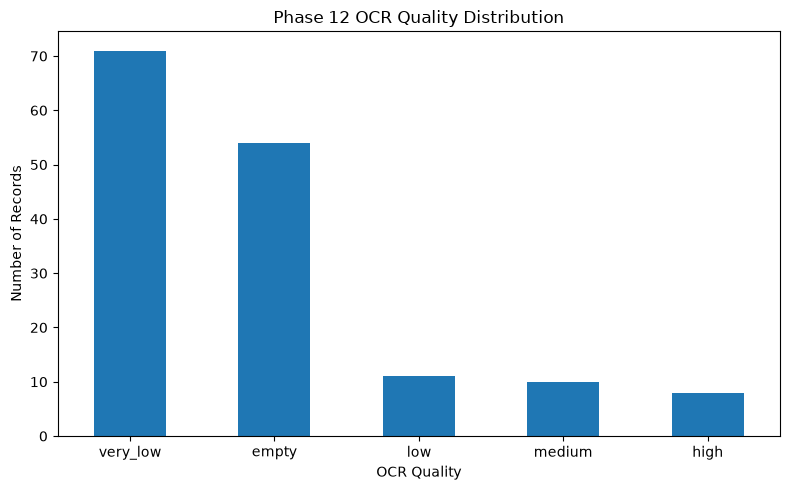

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase12\visualizations\ocr_quality_distribution.png


In [44]:
# ============================================================
# CELL 38 — OCR quality distribution
# ============================================================

import matplotlib.pyplot as plt

quality_counts = (
    ocr_manifest_df[
        "ocr_quality"
    ]
    .value_counts()
)

plt.figure(figsize=(8, 5))

quality_counts.plot(
    kind="bar"
)

plt.title(
    "Phase 12 OCR Quality Distribution"
)

plt.xlabel(
    "OCR Quality"
)

plt.ylabel(
    "Number of Records"
)

plt.xticks(
    rotation=0
)

plt.tight_layout()

QUALITY_PLOT_PATH = (
    VIS_DIR /
    "ocr_quality_distribution.png"
)

plt.savefig(
    QUALITY_PLOT_PATH,
    dpi=200,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    QUALITY_PLOT_PATH
)

In [45]:
# ============================================================
# CELL 39 — Source-wise OCR statistics
# ============================================================

source_stats = (
    ocr_manifest_df
    .groupby("source")
    .agg(
        total_records=("record_key", "count"),
        successful_ocr=("ocr_success", "sum"),
        average_chars=("ocr_char_count", "mean"),
        median_chars=("ocr_char_count", "median"),
        average_words=("ocr_word_count", "mean"),
        average_text_lines=("num_text_lines", "mean")
    )
    .reset_index()
)

source_stats["success_rate"] = (
    source_stats["successful_ocr"] /
    source_stats["total_records"]
)

display(source_stats)

,source,total_records,successful_ocr,average_chars,median_chars,average_words,average_text_lines,success_rate
0,MM-COVID19,30,30,9.000000,5.0,1.466667,1.20000,1.0
1,MMCoVar,50,50,34.900000,1.0,5.980000,2.94000,1.0
2,Med-MMHL,21,21,16.761905,0.0,2.428571,1.47619,1.0
3,ReCOVery,53,53,33.924528,1.0,5.849057,2.90566,1.0


In [46]:
# ============================================================
# CELL 40 — Save source-wise statistics
# ============================================================

SOURCE_STATS_PATH = (
    METRICS_DIR /
    "source_wise_ocr_stats.csv"
)

source_stats.to_csv(
    SOURCE_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:",
    SOURCE_STATS_PATH
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\source_wise_ocr_stats.csv


In [47]:
# ============================================================
# CELL 41 — Split-wise OCR statistics
# ============================================================

split_stats = (
    ocr_manifest_df
    .groupby("phase11_split")
    .agg(
        total_records=("record_key", "count"),
        successful_ocr=("ocr_success", "sum"),
        average_chars=("ocr_char_count", "mean"),
        median_chars=("ocr_char_count", "median"),
        average_words=("ocr_word_count", "mean"),
        average_text_lines=("num_text_lines", "mean")
    )
    .reset_index()
)

split_stats["success_rate"] = (
    split_stats["successful_ocr"] /
    split_stats["total_records"]
)

display(split_stats)

,phase11_split,total_records,successful_ocr,average_chars,median_chars,average_words,average_text_lines,success_rate
0,MM-COVID19,30,30,9.000000,5.0,1.466667,1.20000,1.0
1,MMCoVar,50,50,34.900000,1.0,5.980000,2.94000,1.0
2,Med-MMHL,21,21,16.761905,0.0,2.428571,1.47619,1.0
3,ReCOVery,53,53,33.924528,1.0,5.849057,2.90566,1.0


In [48]:
# ============================================================
# CELL 42 — Save split-wise statistics
# ============================================================

SPLIT_STATS_PATH = (
    METRICS_DIR /
    "split_wise_ocr_stats.csv"
)

split_stats.to_csv(
    SPLIT_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:",
    SPLIT_STATS_PATH
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\split_wise_ocr_stats.csv


In [49]:
# ============================================================
# CELL 43 — Inspect OCR samples
# ============================================================

sample_df = (
    ocr_manifest_df[
        (ocr_manifest_df["ocr_success"] == True) &
        (ocr_manifest_df["ocr_char_count"] > 0)
    ]
    .sample(
        min(
            10,
            len(
                ocr_manifest_df[
                    (ocr_manifest_df["ocr_success"] == True) &
                    (ocr_manifest_df["ocr_char_count"] > 0)
                ]
            )
        ),
        random_state=42
    )
)

for _, row in sample_df.iterrows():

    print("=" * 80)

    print("Record:", row["record_key"])
    print("Source:", row["source"])
    print("Label:", row["label"])
    print("Split:", row["phase11_split"])

    print("\nOCR text:")
    print(row["ocr_text"])

    print()

Record: record_000130
Source: ReCOVery
Label: 0
Split: ReCOVery

OCR text:
U

Record: record_000075
Source: MMCoVar
Label: 1
Split: MMCoVar

OCR text:
D:Mitel
oMitel
Mitel

Record: record_000109
Source: ReCOVery
Label: 0
Split: ReCOVery

OCR text:
NORETURN
TO NORMAL
NATED PEOPLE STILL FACE RESTRICTIONS
Standing Up For What's Right."

Record: record_000064
Source: MMCoVar
Label: 1
Split: MMCoVar

OCR text:
0

Record: record_000063
Source: MMCoVar
Label: 1
Split: MMCoVar

OCR text:
KITE

Record: record_000055
Source: MMCoVar
Label: 1
Split: MMCoVar

OCR text:
1837-

Record: record_000024
Source: MM-COVID19
Label: 1
Split: MM-COVID19

OCR text:
WebMD

Record: record_000127
Source: ReCOVery
Label: 0
Split: ReCOVery

OCR text:
WORKMAN
45

Record: record_000010
Source: MM-COVID19
Label: 1
Split: MM-COVID19

OCR text:
WebMD

Record: record_000000
Source: MM-COVID19
Label: 1
Split: MM-COVID19

OCR text:
WebMD



In [50]:
# ============================================================
# CELL 44 — Label-wise OCR statistics
# ============================================================

label_stats = (
    ocr_manifest_df
    .groupby("label")
    .agg(
        total_records=("record_key", "count"),
        successful_ocr=("ocr_success", "sum"),
        average_chars=("ocr_char_count", "mean"),
        median_chars=("ocr_char_count", "median"),
        average_words=("ocr_word_count", "mean"),
        average_text_lines=("num_text_lines", "mean")
    )
    .reset_index()
)

label_stats["success_rate"] = (
    label_stats["successful_ocr"] /
    label_stats["total_records"]
)

display(label_stats)

,label,total_records,successful_ocr,average_chars,median_chars,average_words,average_text_lines,success_rate
0,0,66,66,30.666667,1.0,5.166667,2.621212,1.0
1,1,88,88,24.329545,5.0,4.125000,2.215909,1.0


In [51]:
# ============================================================
# CELL 45 — Save label-wise statistics
# ============================================================

LABEL_STATS_PATH = (
    METRICS_DIR /
    "label_wise_ocr_stats.csv"
)

label_stats.to_csv(
    LABEL_STATS_PATH,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Saved:",
    LABEL_STATS_PATH
)

Saved: d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\label_wise_ocr_stats.csv


In [52]:
# ============================================================
# CELL 46 — OCR failure report
# ============================================================

ocr_failures = ocr_manifest_df[
    ocr_manifest_df["ocr_success"] == False
].copy()

print(
    "OCR failures:",
    len(ocr_failures)
)

display(
    ocr_failures[
        [
            "record_key",
            "image_path",
            "source",
            "phase11_split",
            "error"
        ]
    ].head(20)
)

OCR failures: 0


,record_key,image_path,source,phase11_split,error


In [53]:
# ============================================================
# CELL 48 — Create Phase 13 claim extraction input
# ============================================================

phase13_df = ocr_manifest_df[
    ocr_manifest_df["ocr_success"] == True
].copy()

phase13_df = phase13_df[
    phase13_df["ocr_text"].fillna("").str.strip() != ""
].copy()

phase13_df = phase13_df[
    [
        "record_key",
        "image_path",
        "label",
        "source",
        "phase11_split",
        "ocr_text",
        "num_text_lines",
        "ocr_char_count",
        "ocr_word_count",
        "ocr_quality"
    ]
].copy()

print(
    "Phase 13 input shape:",
    phase13_df.shape
)

display(
    phase13_df.head()
)

Phase 13 input shape: (100, 10)


,record_key,image_path,label,source,phase11_split,ocr_text,num_text_lines,ocr_char_count,ocr_word_count,ocr_quality
0,record_000000,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
1,record_000001,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
2,record_000002,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
3,record_000003,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low
4,record_000004,D:\downloads\misleading-health-infographic-det...,1,MM-COVID19,MM-COVID19,WebMD,1,5,1,very_low


In [54]:
# ============================================================
# CELL 49 — Save Phase 13 input CSV
# ============================================================

PHASE13_INPUT_CSV = (
    MANIFEST_DIR /
    "phase13_claim_extraction_input.csv"
)

phase13_df.to_csv(
    PHASE13_INPUT_CSV,
    index=False,
    encoding="utf-8-sig"
)

print(
    "Phase 13 input saved:"
)

print(
    PHASE13_INPUT_CSV
)

Phase 13 input saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase13_claim_extraction_input.csv


In [55]:
# ============================================================
# CELL 50 — Save Phase 13 JSONL
# ============================================================

PHASE13_INPUT_JSONL = (
    MANIFEST_DIR /
    "phase13_claim_extraction_input.jsonl"
)

with open(
    PHASE13_INPUT_JSONL,
    "w",
    encoding="utf-8"
) as f:

    for record in phase13_df.to_dict(
        orient="records"
    ):

        f.write(
            json.dumps(
                record,
                ensure_ascii=False,
                default=str
            )
            + "\n"
        )

print(
    "Phase 13 JSONL saved:"
)

print(
    PHASE13_INPUT_JSONL
)

Phase 13 JSONL saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase13_claim_extraction_input.jsonl


In [56]:
# ============================================================
# CELL 51 — Phase 12 summary
# ============================================================

phase12_summary = {

    "phase": "Phase 12 — Full PaddleOCR Integration",

    "total_input_records":
        int(len(ocr_input)),

    "ocr_records_generated":
        int(len(ocr_manifest_df)),

    "successful_ocr":
        int(successful_records),

    "failed_ocr":
        int(failed_records),

    "ocr_success_rate":
        float(success_rate),

    "empty_ocr_records":
        int(len(empty_ocr_df)),

    "nonempty_ocr_records":
        int(len(nonempty_ocr_df)),

    "phase13_input_records":
        int(len(phase13_df)),

    "ocr_results_directory":
        str(OCR_RESULTS_DIR),

    "ocr_manifest":
        str(OCR_MANIFEST_PATH),

    "phase13_input_csv":
        str(PHASE13_INPUT_CSV),

    "phase13_input_jsonl":
        str(PHASE13_INPUT_JSONL)
}

SUMMARY_PATH = (
    METRICS_DIR /
    "ocr_summary.json"
)

with open(
    SUMMARY_PATH,
    "w",
    encoding="utf-8"
) as f:

    json.dump(
        phase12_summary,
        f,
        indent=2,
        ensure_ascii=False
    )

print(
    json.dumps(
        phase12_summary,
        indent=2
    )
)

{
  "phase": "Phase 12 \u2014 Full PaddleOCR Integration",
  "total_input_records": 154,
  "ocr_records_generated": 154,
  "successful_ocr": 154,
  "failed_ocr": 0,
  "ocr_success_rate": 1.0,
  "empty_ocr_records": 54,
  "nonempty_ocr_records": 100,
  "phase13_input_records": 100,
  "ocr_results_directory": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase12\\ocr_results",
  "ocr_manifest": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase12\\manifests\\phase12_ocr_manifest.csv",
  "phase13_input_csv": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase12\\manifests\\phase13_claim_extraction_input.csv",
  "phase13_input_jsonl": "d:\\downloads\\misleading-health-infographic-detection\\outputs\\phase12\\manifests\\phase13_claim_extraction_input.jsonl"
}


In [57]:
# ============================================================
# CELL 52 — Phase 12 human-readable report
# ============================================================

REPORT_PATH = (
    REPORTS_DIR /
    "phase12_report.txt"
)

report_lines = [

    "PHASE 12 — FULL PADDLEOCR INTEGRATION",
    "=" * 60,
    "",

    f"Total input records: {total_records}",

    f"Successful OCR: {successful_records}",

    f"Failed OCR: {failed_records}",

    f"OCR success rate: {success_rate:.2%}",

    f"Empty OCR records: {len(empty_ocr_df)}",

    f"Non-empty OCR records: {len(nonempty_ocr_df)}",

    f"Phase 13 input records: {len(phase13_df)}",

    "",

    "OCR quality distribution:",
    str(
        ocr_manifest_df[
            "ocr_quality"
        ].value_counts()
    ),

    "",

    "Output locations:",
    f"OCR results: {OCR_RESULTS_DIR}",
    f"OCR manifest: {OCR_MANIFEST_PATH}",
    f"Phase 13 CSV: {PHASE13_INPUT_CSV}",
    f"Phase 13 JSONL: {PHASE13_INPUT_JSONL}",

    "",
    "Phase 12 completed."
]

with open(
    REPORT_PATH,
    "w",
    encoding="utf-8"
) as f:

    f.write(
        "\n".join(report_lines)
    )

print(
    "Report saved:"
)

print(REPORT_PATH)

Report saved:
d:\downloads\misleading-health-infographic-detection\outputs\phase12\reports\phase12_report.txt


In [59]:
# ============================================================
# CELL 53 — Final Phase 12 artifact check
# ============================================================

expected_files = [

    OCR_MANIFEST_PATH,

    PHASE13_INPUT_CSV,

    PHASE13_INPUT_JSONL,

    SOURCE_STATS_PATH,

    SPLIT_STATS_PATH,

    LABEL_STATS_PATH,

    SUMMARY_PATH,

    QUALITY_PLOT_PATH,

    REPORT_PATH
]

print(
    "PHASE 12 ARTIFACT CHECK"
)

print("=" * 60)

all_exist = True

for path in expected_files:

    exists = Path(path).exists()

    print(
        f"{'✓' if exists else '✗'} "
        f"{path}"
    )

    if not exists:
        all_exist = False

print("=" * 60)

if all_exist:
    print(
        "ALL EXPECTED PHASE 12 ARTIFACTS EXIST."
    )
else:
    print(
        "Some Phase 12 artifacts are missing."
    )

PHASE 12 ARTIFACT CHECK
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase12_ocr_manifest.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase13_claim_extraction_input.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase13_claim_extraction_input.jsonl
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\source_wise_ocr_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\split_wise_ocr_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\label_wise_ocr_stats.csv
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\metrics\ocr_summary.json
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\visualizations\ocr_quality_distribution.png
✓ d:\downloads\misleading-health-infographic-detection\outputs\phase12\reports\phase12_report.txt
ALL EXPECTED P

In [60]:
# ============================================================
# CELL 54 — Phase 13 handoff sanity check
# ============================================================

print("PHASE 13 HANDOFF CHECK")
print("=" * 60)

print(
    "File:",
    PHASE13_INPUT_CSV
)

print(
    "Exists:",
    PHASE13_INPUT_CSV.exists()
)

print(
    "Records:",
    len(phase13_df)
)

print(
    "Columns:"
)

for column in phase13_df.columns:
    print(" -", column)

print("\nSample OCR text:\n")

if len(phase13_df) > 0:

    sample = phase13_df.iloc[0]

    print(
        sample["ocr_text"][:1000]
    )

else:

    print(
        "WARNING: Phase 13 dataset contains no records."
    )

PHASE 13 HANDOFF CHECK
File: d:\downloads\misleading-health-infographic-detection\outputs\phase12\manifests\phase13_claim_extraction_input.csv
Exists: True
Records: 100
Columns:
 - record_key
 - image_path
 - label
 - source
 - phase11_split
 - ocr_text
 - num_text_lines
 - ocr_char_count
 - ocr_word_count
 - ocr_quality

Sample OCR text:

WebMD
